In [1]:
import pandas as pd

df = pd.read_csv("/content/SAML-D.csv")

df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0.0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0.0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0.0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0.0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0.0,Normal_Cash_Deposits


In [2]:
print(df.columns.tolist())
df.info()

['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500497 entries, 0 to 500496
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    500497 non-null  object 
 1   Date                    500497 non-null  object 
 2   Sender_account          500497 non-null  int64  
 3   Receiver_account        500497 non-null  int64  
 4   Amount                  500497 non-null  float64
 5   Payment_currency        500497 non-null  object 
 6   Received_currency       500497 non-null  object 
 7   Sender_bank_location    500497 non-null  object 
 8   Receiver_bank_location  500497 non-null  object 
 9   Payment_type            500497 non-null  object 
 10  Is_laundering           5004

In [3]:
# Check missing values
df.isnull().sum()

,0
Time,0
Date,0
Sender_account,0
Receiver_account,0
Amount,0
Payment_currency,0
Received_currency,0
Sender_bank_location,0
Receiver_bank_location,0
Payment_type,0


In [4]:
df = df.dropna()

print(df.shape)

(500496, 12)


In [5]:
print(df["Is_laundering"].value_counts())

Is_laundering
0.0    499940
1.0       556
Name: count, dtype: int64


In [6]:
df["Is_laundering"] = df["Is_laundering"].astype(int)

In [9]:
#suspicious rate transaction
suspicious_rate = df["Is_laundering"].mean() * 100

print(f"Suspicious Transaction Rate: {suspicious_rate:.4f}%")

Suspicious Transaction Rate: 0.1111%


In [11]:
#Laundering typologies
df["Laundering_type"].value_counts().head(10)

,count
Laundering_type,
Normal_Small_Fan_Out,185373
Normal_Fan_Out,123325
Normal_Fan_In,113545
Normal_Group,28235
Normal_Cash_Withdrawal,16187
Normal_Cash_Deposits,11104
Normal_Periodical,10687
Normal_Mutual,5608
Normal_Plus_Mutual,2596


In [12]:
#top risky bank locations
suspicious_df = df[df["Is_laundering"] == 1]

suspicious_df["Sender_bank_location"].value_counts().head(10)

,count
Sender_bank_location,
UK,528
Switzerland,5
Japan,3
Mexico,2
Turkey,2
Nigeria,2
UAE,2
France,2
USA,2


In [13]:
# Import network analysis library
import networkx as nx

# Filter suspicious transactions only
suspicious_df = df[df["Is_laundering"] == 1]

# Create transaction network graph
G = nx.from_pandas_edgelist(
    suspicious_df,
    source="Sender_account",
    target="Receiver_account",
    edge_attr="Amount",
    create_using=nx.DiGraph()
)

# Print graph information
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 542
Number of edges: 446


In [14]:
# Detect accounts sending money to many accounts
out_degree = dict(G.out_degree())

# Get top suspicious fan-out accounts
top_fan_out = sorted(
    out_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print(top_fan_out)

[(8600542721, 8), (403526894, 8), (6652024436, 7), (8501920513, 6), (3979625953, 6), (531041847, 6), (3885905606, 6), (6123762963, 6), (2369776263, 5), (8078880434, 5)]


In [15]:
# Detect circular transaction patterns
cycles = list(nx.simple_cycles(G))

# Print detected cycles
print("Number of cycles detected:", len(cycles))
print(cycles[:5])

Number of cycles detected: 0
[]


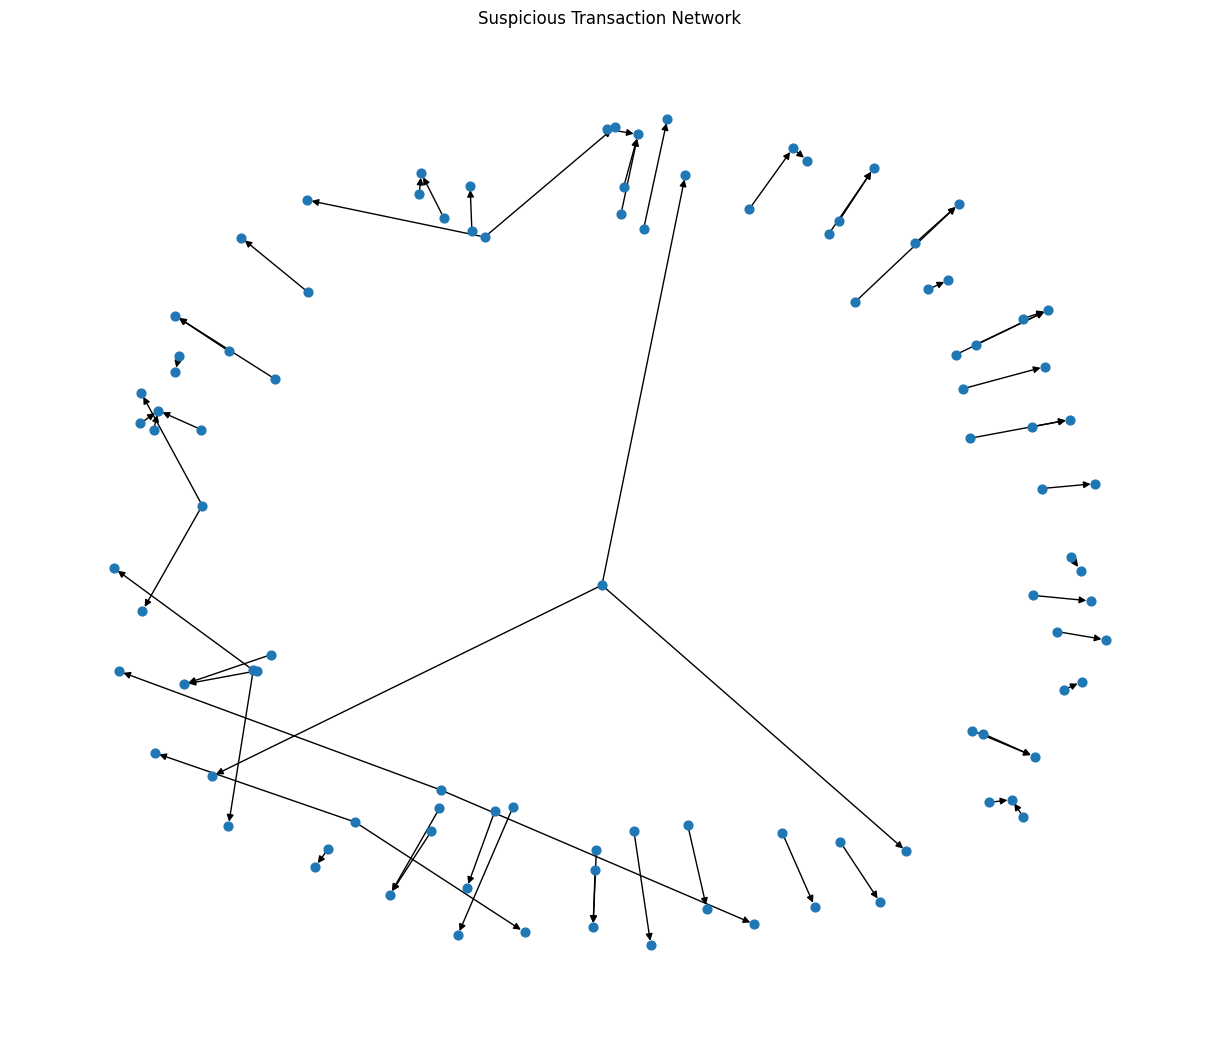

In [16]:
# Import visualization library
import matplotlib.pyplot as plt

# Create graph visualization
plt.figure(figsize=(12,10))

# Use only small sample for visualization
sample_nodes = list(G.nodes())[:100]

# Create subgraph
subgraph = G.subgraph(sample_nodes)

# Draw suspicious transaction network
nx.draw(
    subgraph,
    with_labels=False,
    node_size=40,
    arrowsize=10
)

# Add title
plt.title("Suspicious Transaction Network")

# Show graph
plt.show()

In [17]:
# Calculate account centrality scores
centrality = nx.degree_centrality(G)

# Get top central/highly connected accounts
top_central_accounts = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print(top_central_accounts)

[(4497771501, 0.018484288354898334), (2987279234, 0.0166358595194085), (4723035903, 0.0166358595194085), (7772352930, 0.0166358595194085), (459201377, 0.014787430683918669), (8600542721, 0.014787430683918669), (403526894, 0.014787430683918669), (7856837871, 0.014787430683918669), (6123421761, 0.014787430683918669), (434351836, 0.014787430683918669)]


In [19]:
# Calculate outgoing transaction count
out_degree = dict(G.out_degree())

# Calculate incoming transaction count
in_degree = dict(G.in_degree())

# Create AML risk score dictionary
risk_scores = {}

# Calculate score for each account
for node in G.nodes():

    # Get outgoing connections
    out_score = out_degree.get(node, 0)

    # Get incoming connections
    in_score = in_degree.get(node, 0)

    # Get network centrality score
    centrality_score = centrality.get(node, 0)

    # Calculate final AML risk score
    risk_score = (
        out_score * 2 +
        in_score * 1.5 +
        centrality_score * 100
    )

    # Store score
    risk_scores[node] = risk_score

# Convert scores to dataframe
risk_df = pd.DataFrame({
    "Account": list(risk_scores.keys()),
    "AML_Risk_Score": list(risk_scores.values())
})

# Sort highest-risk accounts
risk_df = risk_df.sort_values(
    by="AML_Risk_Score",
    ascending=False
)

# Show top suspicious accounts
risk_df.head(10)

,Account,AML_Risk_Score
138,8600542721,17.478743
155,403526894,17.478743
7,4497771501,16.848429
298,6652024436,15.293900
9,2987279234,15.163586
190,4723035903,15.163586
207,7772352930,15.163586
310,209742673,13.478743
116,459201377,13.478743
264,434351836,13.478743
